# Aishell-1 Dataset

In [1]:
import torchaudio
import torchaudio.transforms as T
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from IPython.display import Audio, display

In [2]:
!tree data_aishell/wav/train | wc -l

70161


In [ ]:
import os
os.chdir("..")
#next(os.walk("data_aishell/wav/train"))[1]

sizes = []
for _, dirnames, filenames in os.walk("data_aishell/wav/train"):
    sizes.append(len(filenames))

np.array(sizes)

array([  0, 354, 365, 357, 338, 360, 348, 317, 351, 346, 351, 353, 365,
       359, 351, 352, 351, 364, 362, 353, 344, 348, 344, 358, 348, 346,
       362, 364, 350, 339, 312, 336, 331, 345, 357, 336, 337, 344, 333,
       334, 347, 332, 327, 339, 337, 325, 328, 343, 342, 357, 356, 314,
       325, 345, 338, 336, 330, 348, 353, 343, 352, 343, 348, 353, 356,
       358, 360, 359, 367, 362, 354, 352, 334, 339, 355, 349, 356, 357,
       341, 351, 354, 363, 347, 348, 337, 355, 349, 345, 346, 347, 353,
       338, 355, 345, 353, 355, 345, 337, 351, 358, 359, 356, 337, 342,
       346, 335, 347, 352, 351, 344, 361, 365, 353, 358, 368, 359, 351,
       356, 359, 361, 356, 363, 357, 362, 363, 363, 359, 352, 357, 364,
       366, 350, 367, 361, 361, 344, 346, 343, 351, 363, 369, 365, 361,
       359, 351, 351, 355, 364, 351, 353, 355, 368, 357, 349, 367, 354,
       361, 363, 367, 357, 345, 344, 352, 354, 365, 351, 314, 339, 352,
       351, 349, 356, 365, 370, 357, 368, 365, 352, 347, 356, 35

In [4]:
import linecache as lc
import pinyin
import string

line = lc.getline("data_aishell/transcript/aishell_transcript_v0.8.txt", 356)

print(line.rsplit())
pure_chars = ' '.join(line.rsplit()[1:])
pure_pinyin = pinyin.get(pure_chars)

print(f'{pure_chars}: {pure_pinyin}')

['BAC009S0002W0487', '牵动', '了', '全国', '观众', '和', '网友', '的', '心']
牵动 了 全国 观众 和 网友 的 心: qiāndòng le quánguó guānzhòng hé wǎngyǒu de xīn


In [5]:
import os

def get_transcript(trascript_path, filename):
    with open(trascript_path) as f:
        while line := f.readline().rsplit():
            if line[0] == filename[:-4]:
                chars = ' '.join(line[1:])
                return chars, pinyin.get(chars)

get_transcript("data_aishell/transcript/aishell_transcript_v0.8.txt", "BAC009S0002W0122.wav")

('而 对 楼市 成交 抑制 作用 最 大 的 限 购',
 'ér dùi lóushì chéngjiāo yìzhì zuòyòng zùi dà de xiàn gòu')

torch.Size([1, 95984])

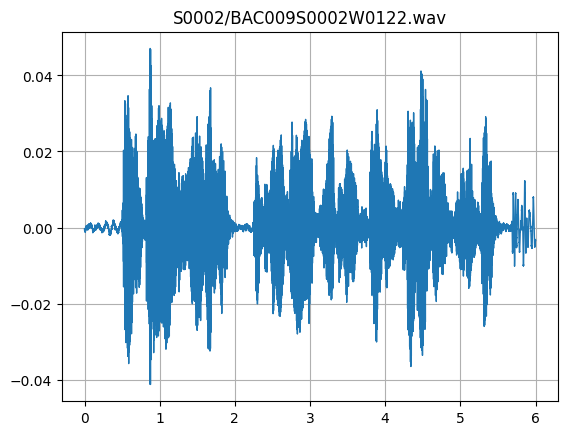

In [6]:
y, sr = torchaudio.load('data_aishell/wav/train/S0002/BAC009S0002W0122.wav')

waveform = y.numpy()
num_channels, num_frames = waveform.shape

time_axis = torch.arange(0, num_frames) / sr

fig, axes = plt.subplots(num_channels, 1)

axes = [axes]
axes[0].plot(time_axis, waveform[0], linewidth=1)
axes[0].grid(True)
axes[0].set_title("S0002/BAC009S0002W0122.wav")

y.shape

torch.Size([600, 80])
而对楼市成交抑制作用最大的限购


/home/szczuru/projects/si-tone/venv/lib64/python3.13/site-packages/torchaudio/functional/functional.py:582: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (80) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


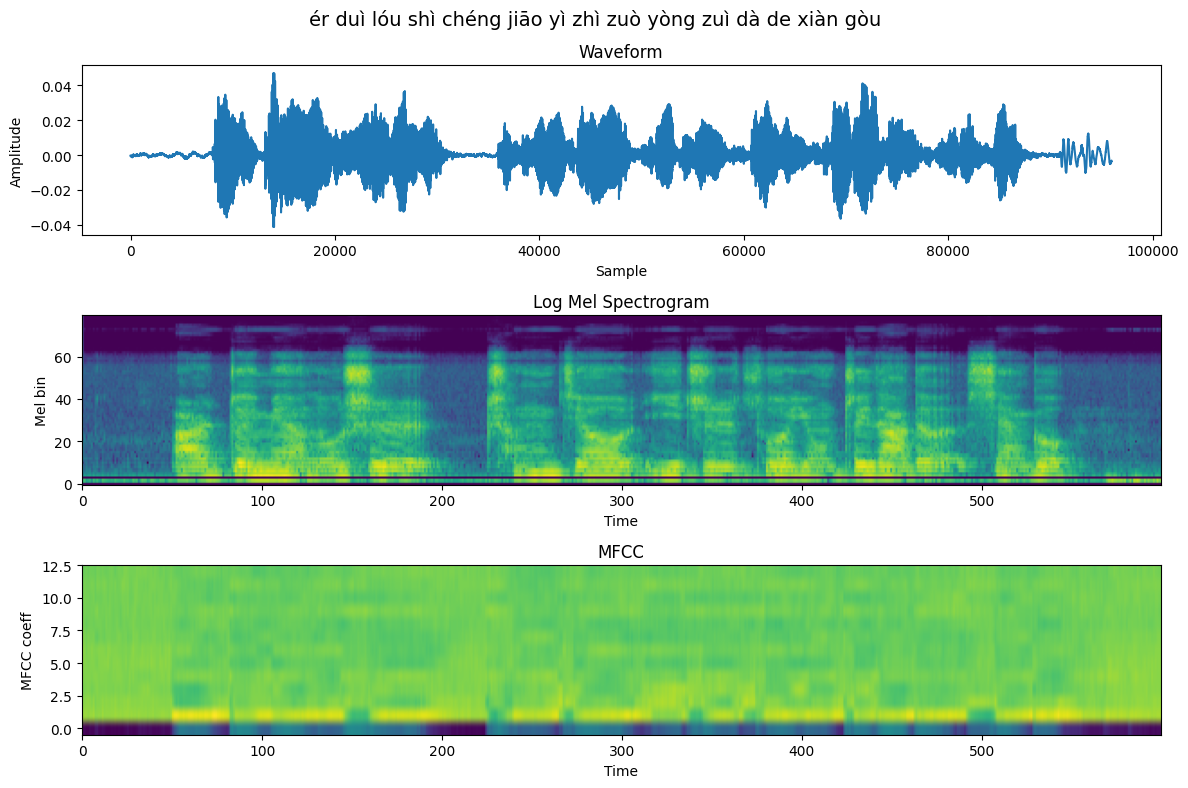

In [9]:
from Aishell import Aishell
from utils.to_pinyin import to_pinyin

dataset = Aishell(path="data_aishell", sample_rate=44100, n_mels=80)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

mel, transcript = dataset[0]
print(mel.shape)
print(transcript)

y, sr = torchaudio.load(dataset.wav_files[0])
display(Audio(y.numpy(), rate=sr))

mfcc_transform = T.MFCC(
    sample_rate=sr,
    n_mfcc=13,
    melkwargs={"n_mels": 80, "n_fft": 512, "hop_length": int(sr * 0.01)}
)
mfcc = mfcc_transform(y)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle(to_pinyin(transcript), fontsize=14)

axes[0].plot(y.squeeze().numpy())
axes[0].set_title("Waveform")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")

axes[1].imshow(mel.T.numpy(), aspect="auto", origin="lower")
axes[1].set_title("Log Mel Spectrogram")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mel bin")

axes[2].imshow(mfcc.squeeze().numpy(), aspect="auto", origin="lower")
axes[2].set_title("MFCC")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("MFCC coeff")

plt.tight_layout()
plt.show()